In [7]:
# ============================================================
# Smart Farming – Irrigation Prediction
# Author: Krisha Shah
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, ConfusionMatrixDisplay,
    classification_report
)
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from imblearn.combine import SMOTETomek

# ── 1. LOAD DATA ────────────────────────────────────────────
from google.colab import files
uploaded = files.upload()  # a button will appear → click → select the xlsx
import io
filename = list(uploaded.keys())[0]
df = pd.read_excel(io.BytesIO(uploaded[filename]))

print("Dataset shape:", df.shape)
print("\nTarget distribution:")
print(df['irrigation_needed'].value_counts())
print(f"\nClass imbalance ratio: {(df['irrigation_needed']==0).sum()} : {(df['irrigation_needed']==1).sum()}")



Saving smart_farming_irrigation_dataset_cleaned.xlsx to smart_farming_irrigation_dataset_cleaned (1).xlsx
Dataset shape: (30000, 21)

Target distribution:
irrigation_needed
0    29871
1      129
Name: count, dtype: int64

Class imbalance ratio: 29871 : 129



Features used: 25
['field_capacity_vol', 'wilting_point_vol', 'root_depth_m', 'surface_soil_moisture_vol', 'rootzone_soil_moisture_vol', 'precip_mm', 'temperature_C', 'humidity_pct', 'wind_speed_m_s', 'solar_radiation_W_m2', 'evapotranspiration_mm', 'crop_type_cotton', 'crop_type_maize', 'crop_type_rice', 'crop_type_soybean', 'crop_type_sugarcane', 'crop_type_wheat', 'soil_texture_clayey', 'soil_texture_loamy', 'soil_texture_sandy', 'crop_stage_flowering', 'crop_stage_grain_fill', 'crop_stage_mature', 'crop_stage_sowing', 'crop_stage_vegetative']

Train: {0: 23897, 1: 103}
Val:   {0: 5974, 1: 26}

After SMOTETomek: {0: 23853, 1: 7125}

--- Threshold Sweep ---
  t=0.10 | Precision=0.500 | Recall=0.962 | F1=0.658
  t=0.15 | Precision=0.556 | Recall=0.962 | F1=0.704
  t=0.20 | Precision=0.595 | Recall=0.962 | F1=0.735
  t=0.25 | Precision=0.610 | Recall=0.962 | F1=0.746
  t=0.30 | Precision=0.658 | Recall=0.962 | F1=0.781
  t=0.35 | Precision=0.676 | Recall=0.885 | F1=0.767
  t=0.40 | Pr

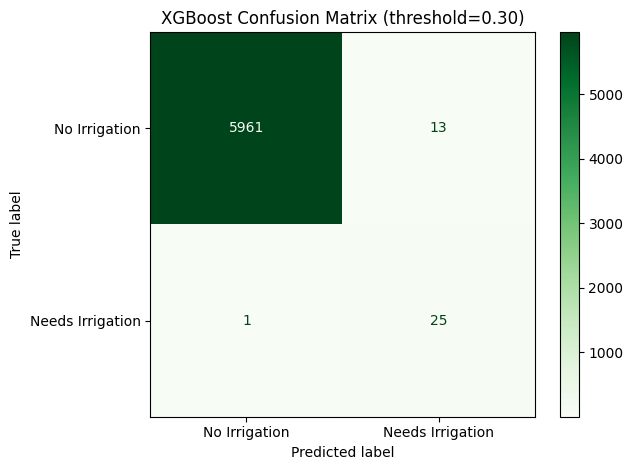


=== Random Forest Results ===
                  precision    recall  f1-score   support

   No Irrigation       1.00      0.98      0.99      5974
Needs Irrigation       0.18      0.85      0.29        26

        accuracy                           0.98      6000
       macro avg       0.59      0.91      0.64      6000
    weighted avg       1.00      0.98      0.99      6000



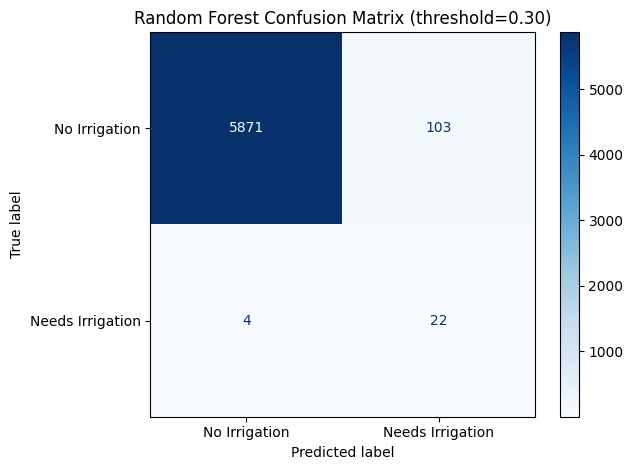


=== Model Comparison (on 'Needs Irrigation' class) ===
Model                 Precision     Recall         F1
----------------------------------------------------
XGBoost                   0.658      0.962      0.781
Random Forest             0.176      0.846      0.291

=== Final Prediction Distribution ===
Predicted_Irrigation
0    29858
1      142
Name: count, dtype: int64

Sample predictions:
  crop_type  surface_soil_moisture_vol  irrigation_needed  \
0     maize                      0.309                  0   
1     maize                      0.294                  0   
2     maize                      0.316                  0   
3     maize                      0.143                  0   
4      rice                      0.282                  0   
5    cotton                      0.253                  0   
6     wheat                      0.371                  0   
7      rice                      0.309                  0   
8    cotton                      0.274             

In [8]:
# ── 2. FEATURE ENGINEERING ──────────────────────────────────
# Exclude: leakage cols, identifiers, target
exclude_cols = [
    'timestamp', 'farm_id', 'lat', 'lon',
    'irrigation_needed',
    'irrigation_amount_mm',  # leakage — only exists when irrigation happens
    'threshold_vol'          # leakage — directly used to compute target
]

feature_cols = [c for c in df.columns if c not in exclude_cols]
cat_features = [c for c in ['crop_type', 'soil_texture', 'crop_stage'] if c in feature_cols]

X = df[feature_cols].copy()
X = pd.get_dummies(X, columns=cat_features)
y = df['irrigation_needed'].astype(int)

print(f"\nFeatures used: {X.shape[1]}")
print(X.columns.tolist())

# ── 3. TRAIN-TEST SPLIT (STRATIFIED) ────────────────────────
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTrain: {y_train.value_counts().to_dict()}")
print(f"Val:   {y_val.value_counts().to_dict()}")

# ── 4. SMOTE-TOMEK (handles extreme imbalance better) ───────
# sampling_strategy=0.3 → minority becomes 30% of majority
smt = SMOTETomek(random_state=42, sampling_strategy=0.3)
X_res, y_res = smt.fit_resample(X_train, y_train)

print(f"\nAfter SMOTETomek: {pd.Series(y_res).value_counts().to_dict()}")

# ── 5. XGBOOST ──────────────────────────────────────────────
neg = (y_res == 0).sum()
pos = (y_res == 1).sum()
spw = neg / pos

xgb_model = XGBClassifier(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=spw,
    eval_metric='aucpr',
    random_state=42,
    n_jobs=-1
)
xgb_model.fit(X_res, y_res)

# ── 6. THRESHOLD TUNING ─────────────────────────────────────
val_probs = xgb_model.predict_proba(X_val)[:, 1]
best_t, best_f1 = 0.5, -1

print("\n--- Threshold Sweep ---")
for t in np.arange(0.10, 0.60, 0.05):
    preds = (val_probs >= t).astype(int)
    if preds.sum() == 0:
        continue
    f1 = f1_score(y_val, preds)
    rec = recall_score(y_val, preds)
    pre = precision_score(y_val, preds)
    print(f"  t={t:.2f} | Precision={pre:.3f} | Recall={rec:.3f} | F1={f1:.3f}")
    if f1 > best_f1:
        best_f1 = f1
        best_t = t

print(f"\n✅ Best Threshold: {best_t:.2f}")

# ── 7. FINAL PREDICTIONS ─────────────────────────────────────
xgb_pred = (val_probs >= best_t).astype(int)

print("\n=== XGBoost Final Results ===")
print(classification_report(y_val, xgb_pred, target_names=['No Irrigation', 'Needs Irrigation']))

cm_xgb = confusion_matrix(y_val, xgb_pred)
ConfusionMatrixDisplay(cm_xgb, display_labels=['No Irrigation', 'Needs Irrigation']).plot(cmap='Greens')
plt.title(f"XGBoost Confusion Matrix (threshold={best_t:.2f})")
plt.tight_layout()
plt.savefig("xgboost_confusion_matrix.png", dpi=150)
plt.show()

# ── 8. RANDOM FOREST (COMPARISON) ───────────────────────────
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_res, y_res)
rf_probs = rf_model.predict_proba(X_val)[:, 1]
rf_pred = (rf_probs >= best_t).astype(int)

print("\n=== Random Forest Results ===")
print(classification_report(y_val, rf_pred, target_names=['No Irrigation', 'Needs Irrigation']))

cm_rf = confusion_matrix(y_val, rf_pred)
ConfusionMatrixDisplay(cm_rf, display_labels=['No Irrigation', 'Needs Irrigation']).plot(cmap='Blues')
plt.title(f"Random Forest Confusion Matrix (threshold={best_t:.2f})")
plt.tight_layout()
plt.savefig("rf_confusion_matrix.png", dpi=150)
plt.show()

# ── 9. MODEL COMPARISON ─────────────────────────────────────
print("\n=== Model Comparison (on 'Needs Irrigation' class) ===")
print(f"{'Model':<20} {'Precision':>10} {'Recall':>10} {'F1':>10}")
print("-" * 52)
for name, pred in [("XGBoost", xgb_pred), ("Random Forest", rf_pred)]:
    p = precision_score(y_val, pred)
    r = recall_score(y_val, pred)
    f = f1_score(y_val, pred)
    print(f"{name:<20} {p:>10.3f} {r:>10.3f} {f:>10.3f}")

# ── 10. FULL DATASET PREDICTION ─────────────────────────────
df['Predicted_Irrigation'] = (xgb_model.predict_proba(X)[:, 1] >= best_t).astype(int)

print("\n=== Final Prediction Distribution ===")
print(df['Predicted_Irrigation'].value_counts())
print("\nSample predictions:")
print(df[['crop_type', 'surface_soil_moisture_vol', 'irrigation_needed', 'Predicted_Irrigation']].head(10))